In [2]:
import requests
import pandas as pd
import numpy as np

Fetch the data from the api's

In [3]:
def fetch_jan_2024_data():
    actual_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/FUELHH/stream"
    actual_params = {
        "fuelType": "WIND",
        "settlementDateFrom": "2024-01-01",
        "settlementDateTo": "2024-01-31"
    }
    actual_res = requests.get(actual_url, params=actual_params)
    actual_df = pd.DataFrame(actual_res.json())

    forecast_url = "https://data.elexon.co.uk/bmrs/api/v1/datasets/WINDFOR/stream"
    forecast_params = {
        "publishDateTimeFrom": "2023-12-30T00:00:00Z",
        "publishDateTimeTo": "2024-01-31T23:59:59Z"
    }

    forecast_res = requests.get(forecast_url, params=forecast_params)
    forecast_df = pd.DataFrame(forecast_res.json())

    return actual_df, forecast_df

actual_df, forecast_df = fetch_jan_2024_data()

print(f"Actual Rows Fetched: {len(actual_df)}")
print(f"Forecast Rows Fetched: {len(forecast_df)}")

Actual Rows Fetched: 1488
Forecast Rows Fetched: 12936


checking the structure of the columns

In [4]:
print("Actual columns:", actual_df.columns.tolist())
print("Forecast columns:", forecast_df.columns.tolist())

Actual columns: ['dataset', 'publishTime', 'startTime', 'settlementDate', 'settlementPeriod', 'fuelType', 'generation']
Forecast columns: ['dataset', 'publishTime', 'startTime', 'generation']


Cleanup

In [5]:

actual_df['startTime'] = pd.to_datetime(actual_df['startTime']).dt.tz_localize(None)
forecast_df['startTime'] = pd.to_datetime(forecast_df['startTime']).dt.tz_localize(None)
forecast_df['publishTime'] = pd.to_datetime(forecast_df['publishTime']).dt.tz_localize(None)


Filter forecast to only include target period (Jan 2024)

In [6]:
forecast_df = forecast_df[(forecast_df['startTime'] >= '2024-01-01') & (forecast_df['startTime'] <= '2024-01-31 23:59:59')]

In [7]:

actual_df['generation'] = pd.to_numeric(actual_df['generation'], errors='coerce')
forecast_df['generation'] = pd.to_numeric(forecast_df['generation'], errors='coerce')

# Match frequencies (Hourly)
actual_df['match_time'] = actual_df['startTime'].dt.floor('h')
forecast_df['match_time'] = forecast_df['startTime'].dt.floor('h')


Keep the most recent forecast published for each hour

In [8]:

forecast_unique = forecast_df.sort_values('publishTime').drop_duplicates('match_time', keep='last')
# Merge
merged_df = pd.merge(
    actual_df.groupby('match_time')['generation'].mean().reset_index(),
    forecast_unique[['match_time', 'generation', 'publishTime']],
    on='match_time',
    suffixes=('_actual', '_forecast')
)

print(f"Corrected Merged Dataset Rows: {len(merged_df)}")
display(merged_df.head(3))

Corrected Merged Dataset Rows: 744


,match_time,generation_actual,generation_forecast,publishTime
0,2024-01-01 00:00:00,10623.5,11453,2023-12-31 22:30:00
1,2024-01-01 01:00:00,11220.5,11838,2023-12-31 22:30:00
2,2024-01-01 02:00:00,11335.5,12090,2023-12-31 22:30:00


Error calculation and graph **plotting**

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Calculate Error Metrics
mae = mean_absolute_error(merged_df['generation_actual'], merged_df['generation_forecast'])
rmse = np.sqrt(mean_squared_error(merged_df['generation_actual'], merged_df['generation_forecast']))

print(f"mean absolute error: {mae:.2f} MW")
print(f"root mean squared error: {rmse:.2f} MW")


mean absolute error: 1836.11 MW
root mean squared error: 2443.10 MW


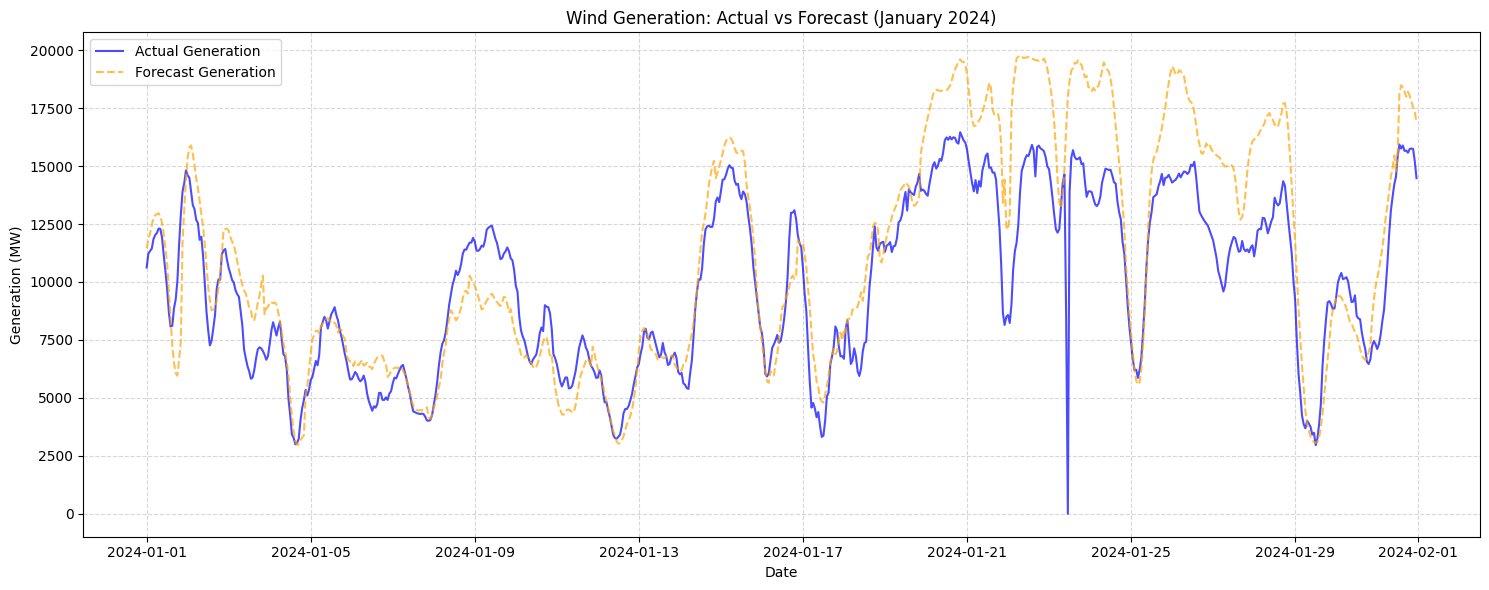

In [10]:
# 2. Visualization
plt.figure(figsize=(15, 6))
plt.plot(merged_df['match_time'], merged_df['generation_actual'], label='Actual Generation', color='blue', alpha=0.7)
plt.plot(merged_df['match_time'], merged_df['generation_forecast'], label='Forecast Generation', color='orange', linestyle='--', alpha=0.7)

plt.title('Wind Generation: Actual vs Forecast (January 2024)')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [73]:
# 3. Daily Error Analysis
merged_df['error'] = merged_df['generation_actual'] - merged_df['generation_forecast']
merged_df['day'] = merged_df['match_time'].dt.date

daily_metrics = merged_df.groupby('day').apply(lambda x: pd.Series({
    'MAE': mean_absolute_error(x['generation_actual'], x['generation_forecast']),
    'Avg_Actual': x['generation_actual'].mean()
})).reset_index()

display(daily_metrics.head())

/tmp/ipykernel_14377/2742466339.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_metrics = merged_df.groupby('day').apply(lambda x: pd.Series({


,day,MAE,Avg_Actual
0,2024-01-01,1518.437500,11206.395833
1,2024-01-02,1226.604167,10929.854167
2,2024-01-03,2111.145833,7750.020833
3,2024-01-04,703.604167,5724.520833
4,2024-01-05,596.666667,7442.666667


Mean Forecast Error: -1179.67


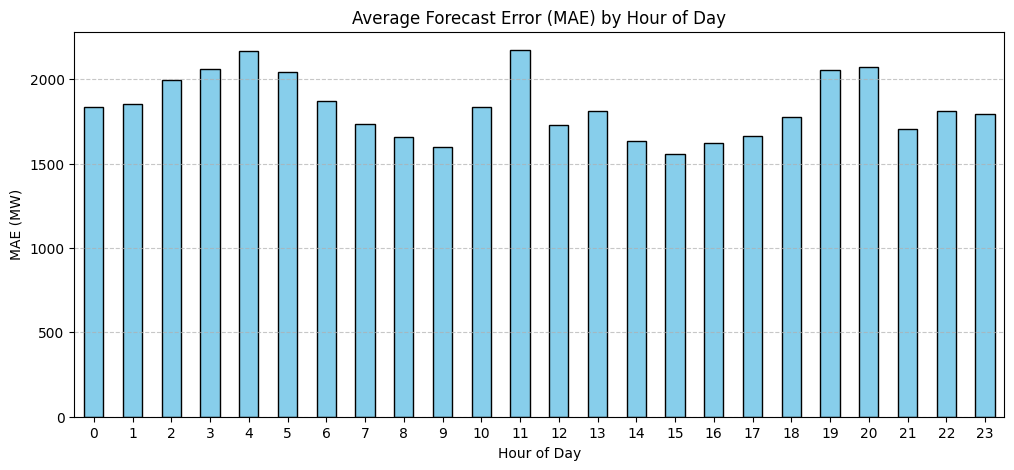

In [74]:
# 1. Bias Analysis (Mean Forecast Error)
bias = merged_df['error'].mean()
print(f"Mean Forecast Error: {bias:.2f}")

# 2. Hourly Error Profile
merged_df['hour'] = merged_df['match_time'].dt.hour
hourly_mae = merged_df.groupby('hour')['error'].apply(lambda x: np.abs(x).mean())

plt.figure(figsize=(12, 5))
hourly_mae.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Average Forecast Error (MAE) by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('MAE (MW)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()